In [ ]:
import numpy as np
# Exemplo de dados
X = np.array([1.47, 1.50, 1.52, 1.55, 1.57, 1.60, 1.63, 1.65, 1.68, 1.70,
1.73, 1.75, 1.78, 1.80, 1.83])
Y = np.array([52.21, 53.12, 54.48, 55.84, 57.20, 58.57, 59.93, 61.29,
63.11, 64.47, 66.28, 68.10, 69.92, 72.19, 74.46])

In [ ]:
size = np.size(X)
sumX = np.sum(X)
sumY = np.sum(Y)
sumXX = np.sum(X*X)
sumXY = np.sum(X*Y)

beta1 = (size*sumXY - sumX*sumY)/(size*sumXX - (sumX* sumX))
beta0 = (sumY - beta1*sumX)/size

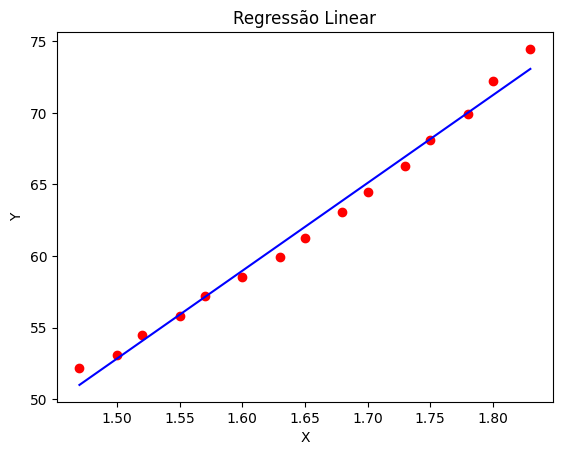

In [ ]:
# prompt: Crie uma função para prever os valores utilizando os coeficientes e trace a reta de regressão em um
# gráfico

Y_pred = beta0 + beta1*X

import matplotlib.pyplot as plt

def predict_and_plot(X, Y, beta0, beta1):
  """
  Predicts values using the given coefficients and plots the regression line.

  Args:
    X: Input values (independent variable).
    Y: Actual output values (dependent variable).
    beta0: Intercept of the regression line.
    beta1: Slope of the regression line.
  """
  # Plotagem
  plt.scatter(X, Y, color='red')
  plt.plot(X, Y_pred, color='blue')

  plt.title('Regressão Linear')
  plt.xlabel('X')
  plt.ylabel('Y')

  plt.show()

# Exemplo de uso com os dados fornecidos:
predict_and_plot(X, Y, beta0, beta1)

In [ ]:
RSE = np.sqrt(np.sum((Y - Y_pred)**2)/(size-2))
R2 = np.sum((Y - Y_pred)**2)/np.var(Y)
print(RSE, R2)

0.7590762809485331 0.16204616331304625


In [ ]:
import seaborn as sns
from sklearn.model_selection import train_test_split
# Carregar o dataset de gorjetas
df = sns.load_dataset('tips')
# Mostrar as primeiras linhas do DataFrame
print(df.head())
# Selecionar a variável independente (total_bill) e a variável dependente (tip)
X = df[['total_bill']] # Total da conta
Y = df['tip'] # Gorjeta
# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2,
random_state=42)

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


Erro Quadrático Médio (RSE): 0.7541977545199625
Coeficiente de Determinação (R²): 0.5449381659234664
Coeficiente da Regressão: 0.10696370685268658
Intercepto: 0.925235558557056


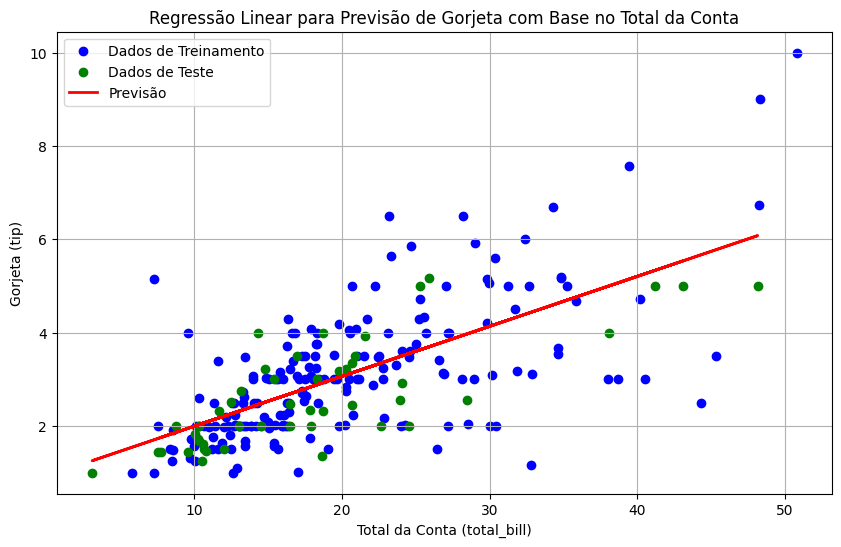

Previsão de gorjeta para uma conta de 80 USD: 9.48 USD


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Carregar o dataset de gorjetas
df = sns.load_dataset('tips')

# Selecionar a variável independente (total_bill) e a variável dependente (tip)
X = df[['total_bill']]  # Total da conta
y = df['tip']  # Gorjeta

# Dividir os dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar e ajustar o modelo de regressão linear
model = LinearRegression()
model.fit(X_train, y_train)

# Fazer previsões nos dados de teste
y_pred = model.predict(X_test)

# Calcular o erro quadrático médio (RSE) e o R^2
rse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Coeficiente e intercepto da regressão
coef = model.coef_[0]
intercept = model.intercept_

# Exibir os resultados
print(f"Erro Quadrático Médio (RSE): {rse}")
print(f"Coeficiente de Determinação (R²): {r2}")
print(f"Coeficiente da Regressão: {coef}")
print(f"Intercepto: {intercept}")

# Plotar o gráfico com grade
plt.figure(figsize=(10, 6))
# Dados de treinamento
plt.scatter(X_train, y_train, color='blue', label='Dados de Treinamento')
# Dados de teste
plt.scatter(X_test, y_test, color='green', label='Dados de Teste')
# Previsão nos dados de teste
plt.plot(X_test, y_pred, color='red', label='Previsão', linewidth=2)

plt.xlabel('Total da Conta (total_bill)')
plt.ylabel('Gorjeta (tip)')
plt.title('Regressão Linear para Previsão de Gorjeta com Base no Total da Conta')
plt.legend()
plt.grid(True)  # Adicionar a grade ao gráfico
plt.show()

# Prever o valor da gorjeta para uma conta de 80 USD
total_bill_example = np.array([[80]])  # Conta de 80 USD
predicted_tip = model.predict(total_bill_example)
print(f"Previsão de gorjeta para uma conta de 80 USD: {predicted_tip[0]:.2f} USD")